In [1]:
import json
import matplotlib.pyplot as plt

TRAINING_LOG = "results/sgd_gate_run/training_log.json"

with open(TRAINING_LOG) as f:
    log = json.load(f)

iters = [e["iteration"] for e in log if "gating" in e]
promoted_iters = [e["iteration"] for e in log if e.get("gating", {}).get("promoted")]
retained_iters = [e["iteration"] for e in log if "gating" in e and not e["gating"].get("promoted")]

print(f"Iters: {len(iters)}  promoted: {len(promoted_iters)}  retained: {len(retained_iters)}")
print(f"Overall promotion rate: {len(promoted_iters) / len(iters):.1%}")

Iters: 196  promoted: 77  retained: 119
Overall promotion rate: 39.3%


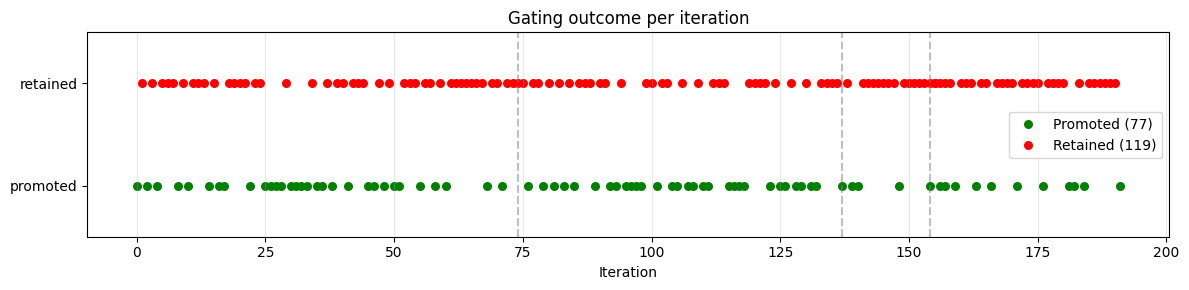

In [2]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(promoted_iters, [1] * len(promoted_iters), c="green", s=30, label=f"Promoted ({len(promoted_iters)})")
ax.scatter(retained_iters, [2] * len(retained_iters), c="red", s=30, label=f"Retained ({len(retained_iters)})")
for x in (74, 137, 154):
    ax.axvline(x, color="grey", linestyle="--", alpha=0.5)
ax.set_yticks([1, 2], ["promoted", "retained"])
ax.set_ylim(0.5, 2.5)
ax.set_xlabel("Iteration")
ax.set_title("Gating outcome per iteration")
ax.grid(True, axis="x", alpha=0.3)
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

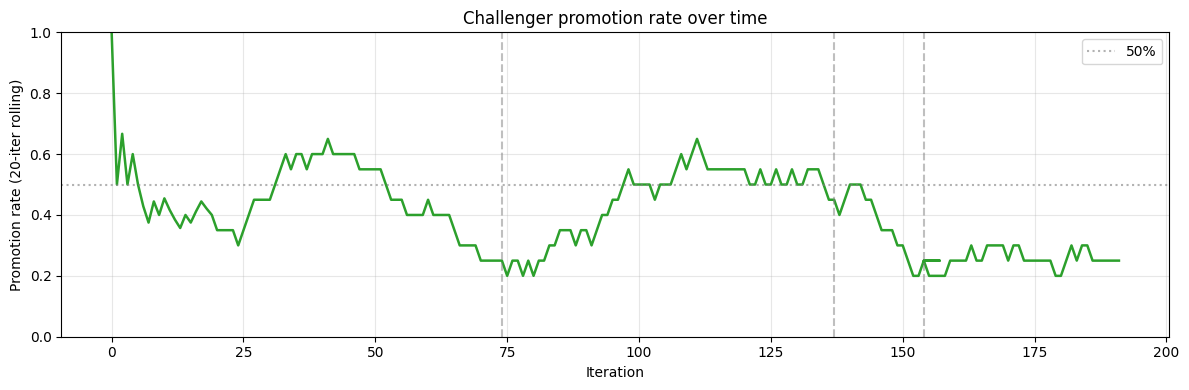

In [3]:
# Rolling promotion rate to make the trend obvious.
WINDOW = 20
promoted_flags = [1 if e.get("gating", {}).get("promoted") else 0 for e in log if "gating" in e]
rolling = [
    sum(promoted_flags[max(0, i - WINDOW + 1) : i + 1]) / min(WINDOW, i + 1)
    for i in range(len(promoted_flags))
]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(iters, rolling, linewidth=1.8, color="C2")
ax.axhline(0.5, color="grey", linestyle=":", alpha=0.6, label="50%")
for x in (74, 137, 154):
    ax.axvline(x, color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Iteration")
ax.set_ylabel(f"Promotion rate ({WINDOW}-iter rolling)")
ax.set_title("Challenger promotion rate over time")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()